# BTYD from zero to useful - PyMC version, no `lifetimes`

This notebook tells the same story as `BTYD_Intro_End_to_End_Project.ipynb`, but removes the `lifetimes` package completely.

We will still do the same BTYD project:

- Generate non-contractual transaction data.
- Build RFM features by hand.
- Fit a BG/NBD transaction model with PyMC-Marketing.
- Fit a Gamma-Gamma spend model with PyMC-Marketing.
- Validate on a holdout window.
- Turn predictions into CLV and a customer action table.
- Then collect the actual Bayesian payoff: full posteriors with credible intervals, via MCMC.

The goal is not to make PyMC look mysterious. The goal is to show that the same business logic can be expressed as a probabilistic model.

Inspiration checked: the Tensor House Bayesian BTYD notebook implements BG/NBD and Gamma-Gamma in PyMC from RFM data. This notebook keeps that spirit, but uses the maintained PyMC-Marketing API so the code is readable for juniors.

## 1. What changes when we move from `lifetimes` to PyMC?

The business problem does not change.

| Question | Same BTYD idea | PyMC version |
|---|---|---|
| Is the customer still active? | `P(alive)` | posterior or MAP estimate from a probabilistic model |
| How many purchases will happen next? | expected future transactions | `BetaGeoModel.expected_purchases()` |
| How much will each purchase be worth? | expected average order value | `GammaGammaModel.expected_customer_spend()` |
| What is expected customer value? | future purchases x expected spend | expected CLV with discounting |

The practical tradeoff:

- `lifetimes` is fast and beginner-friendly.
- PyMC-Marketing is slower but extensible, Bayesian, and uncertainty-aware.

For the walkthrough we use MAP fitting for speed. MAP (maximum a posteriori) is the mode of the posterior - the parameter point that maximizes prior times likelihood. Two honest caveats: `find_MAP` optimizes in a transformed parameter space, so the point it returns is approximate rather than the exact mode; and a single point carries no uncertainty at all. In section 8 we pay the full price and run MCMC, which is where the Bayesian machinery actually earns its keep.

In [1]:
import warnings

import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Targeted filters only: a blanket "ignore" would also hide warnings we want,
# like sampler divergences or numerical problems during fitting.
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

from pymc_marketing import clv
from pymc_extras.prior import Prior

## 2. The same story: Bean & Byte coffee customers

We use the exact same synthetic business as the `lifetimes` notebook: same generator, same seed, same 1,400 customers. Both notebooks literally analyze the same simulated world, so every number is comparable across the two.

The simulation is written to follow the BG/NBD and Gamma-Gamma assumptions exactly: each customer buys as a Poisson process with a personal rate while "alive", flips a personal dropout coin after every repeat purchase, and draws order values from a Gamma distribution with a personal spend parameter. The true population parameters are stored as constants, which lets us check the fitted model against the truth later - a luxury real data never grants.

The customer can buy whenever they want. There is no cancellation date. Silence might mean churn, or it might just mean the customer is waiting until they need coffee again.

In [2]:
RANDOM_SEED = 20260704

# Ground-truth population parameters (stored so the fitted model can be
# validated against the simulated truth later).
R_TRUE, ALPHA_TRUE = 1.3, 45.0   # purchase rate: lambda_i ~ Gamma(r, rate=alpha), purchases/day
A_TRUE, B_TRUE = 1.1, 3.3        # dropout: p_i ~ Beta(a, b), coin flipped after each repeat purchase
P_SHAPE = 6.0                    # order value: z ~ Gamma(p, rate=nu_i), E[z | nu_i] = p / nu_i
Q_TRUE, GAMMA_TRUE = 4.0, 20.0   # spend heterogeneity: nu_i ~ Gamma(q, rate=gamma)


def simulate_transactions(n_customers=1400, seed=RANDOM_SEED):
    """Simulate a coffee retailer that follows the BG/NBD + Gamma-Gamma
    assumptions exactly:

    - while alive, each customer buys as a Poisson process with personal
      rate lambda_i ~ Gamma(r, alpha);
    - after EVERY repeat purchase the customer drops out for good with
      personal probability p_i ~ Beta(a, b) (the "buy till you die" coin);
    - order values are Gamma(p, nu_i), with spend heterogeneity
      nu_i ~ Gamma(q, gamma) across customers (the Gamma-Gamma story).

    Because this simulated world matches the model's assumptions, we can
    validate the fitted model against stored ground truth later. Real data
    never matches this cleanly - which is exactly why the validation
    section matters. The function seeds its own generator, so re-running
    this cell alone reproduces the same data.
    """
    rng = np.random.default_rng(seed)
    obs_start = pd.Timestamp("2024-01-01")
    obs_end = pd.Timestamp("2025-12-31")
    max_signup_offset = 420  # signups spread over the first 14 months

    customer_rows, tx_rows = [], []
    for i in range(n_customers):
        cid = f"BB{i:05d}"
        signup = obs_start + pd.Timedelta(days=int(rng.integers(0, max_signup_offset + 1)))
        lam = rng.gamma(shape=R_TRUE, scale=1.0 / ALPHA_TRUE)
        p_drop = rng.beta(A_TRUE, B_TRUE)
        nu = rng.gamma(shape=Q_TRUE, scale=1.0 / GAMMA_TRUE)

        def order_value():
            return round(max(float(rng.gamma(shape=P_SHAPE, scale=1.0 / nu)), 2.0), 2)

        # First purchase at signup. In BG/NBD the dropout coin is flipped
        # after each REPEAT purchase, not after the very first one.
        tx_rows.append((cid, signup.normalize(), order_value()))
        alive, t = True, signup
        while alive:
            t = t + pd.Timedelta(days=float(rng.exponential(1.0 / lam)))
            if t > obs_end:
                break
            tx_rows.append((cid, t.normalize(), order_value()))
            if rng.random() < p_drop:
                alive = False

        customer_rows.append((cid, signup.normalize(), lam, p_drop, P_SHAPE / nu, alive))

    transactions = (pd.DataFrame(tx_rows, columns=["customer_id", "order_date", "order_value"])
                      .sort_values(["customer_id", "order_date"]).reset_index(drop=True))
    customers = pd.DataFrame(customer_rows, columns=[
        "customer_id", "signup_date", "latent_daily_rate", "latent_dropout_prob",
        "latent_mean_order_value", "alive_at_observation_end_hidden"])
    return transactions, customers, obs_end


transactions, customers, observation_end = simulate_transactions()
print("transactions:", transactions.shape)
print("customers:", customers.shape)
print("observation end:", observation_end.date())
transactions.head()

transactions: (8045, 3)
customers: (1400, 6)
observation end: 2025-12-31


,customer_id,order_date,order_value
0,BB00000,2024-01-01,36.54
1,BB00000,2024-01-08,29.27
2,BB00001,2024-10-16,46.42
3,BB00001,2024-10-18,55.73
4,BB00001,2024-10-25,77.61


In [3]:
summary = transactions.groupby("customer_id").agg(
    first_purchase=("order_date", "min"),
    last_purchase=("order_date", "max"),
    orders=("order_date", "count"),
    total_revenue=("order_value", "sum"),
    avg_order_value=("order_value", "mean"),
).reset_index()
summary["customer_age_days"] = (observation_end - summary["first_purchase"]).dt.days
summary["days_since_last_order"] = (observation_end - summary["last_purchase"]).dt.days
summary.describe().round(2)

,first_purchase,last_purchase,orders,total_revenue,avg_order_value,customer_age_days,days_since_last_order
count,1400,1400,1400.00,1400.00,1400.00,1400.00,1400.00
mean,2024-07-30 15:56:34.285714432,2025-02-11 22:00:41.142856960,5.75,230.15,41.02,518.34,322.08
min,2024-01-01 00:00:00,2024-01-01 00:00:00,1.00,13.00,7.45,310.00,1.00
25%,2024-04-18 12:00:00,2024-09-18 18:00:00,2.00,71.50,23.68,419.00,156.00
50%,2024-07-28 00:00:00,2025-02-01 00:00:00,4.00,134.15,33.26,521.00,333.00
75%,2024-11-07 00:00:00,2025-07-28 00:00:00,7.00,264.46,49.06,621.50,468.25
max,2025-02-24 00:00:00,2025-12-30 00:00:00,65.00,2577.55,496.45,730.00,730.00
std,NaN,NaN,5.91,287.30,32.41,120.46,197.45


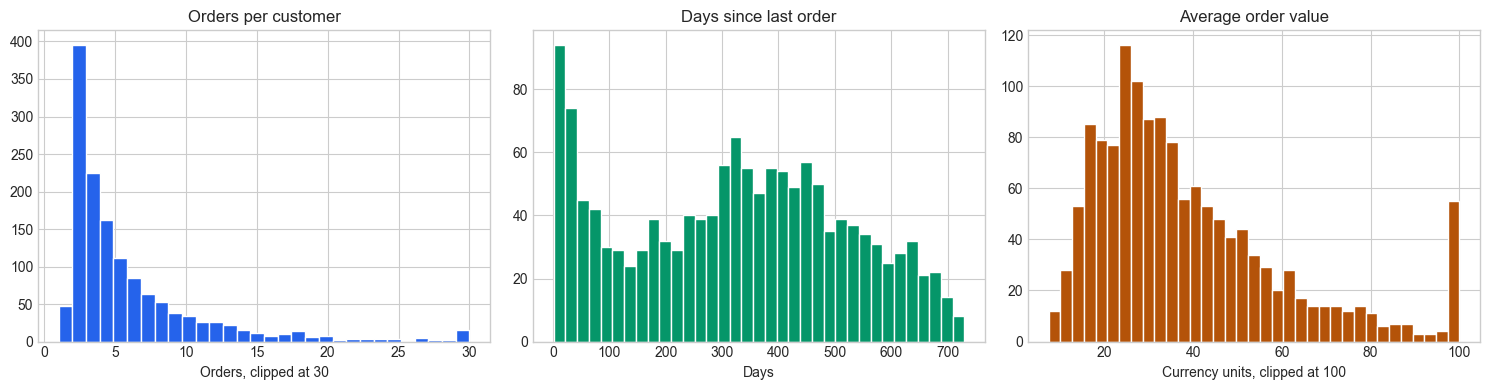

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(summary["orders"].clip(upper=30), bins=30, color="#2563EB", edgecolor="white")
axes[0].set_title("Orders per customer")
axes[0].set_xlabel("Orders, clipped at 30")
axes[1].hist(summary["days_since_last_order"], bins=35, color="#059669", edgecolor="white")
axes[1].set_title("Days since last order")
axes[1].set_xlabel("Days")
axes[2].hist(summary["avg_order_value"].clip(upper=100), bins=35, color="#B45309", edgecolor="white")
axes[2].set_title("Average order value")
axes[2].set_xlabel("Currency units, clipped at 100")
plt.tight_layout()
plt.show()

## 3. Build RFM by hand

This is the first important difference from the previous notebook.

We do not call `lifetimes.utils.summary_data_from_transaction_data`. We compute the BTYD input table ourselves:

- `frequency`: repeat purchase occasions after the first one.
- `recency`: days from first purchase to latest purchase.
- `T`: days from first purchase to observation end.
- `monetary_value`: average value of repeat purchase occasions.

One convention matters here: we first collapse the transaction log to one row per customer per day, so same-day orders count as a single purchase occasion. This matches the `lifetimes` `freq="D"` convention and the Fader-Hardie definition of "repeat purchase occasions", which keeps this notebook numerically aligned with its sibling.

This is worth learning because most real projects have messy definitions: refunds, multiple stores, subscription bundles, fraud, cancelled orders, and time zones.

In [5]:
def build_rfm_by_hand(transactions, observation_end):
    # Step 1: collapse to one row per (customer, day). Same-day orders count
    # as ONE purchase occasion and their values are summed - the lifetimes
    # freq="D" convention.
    daily = (
        transactions.groupby(["customer_id", "order_date"], as_index=False)["order_value"].sum()
    )

    # Step 2: frequency / recency / T from the purchase-day level.
    per_customer = daily.groupby("customer_id").agg(
        first_purchase=("order_date", "min"),
        last_purchase=("order_date", "max"),
        purchase_days=("order_date", "count"),
    )
    per_customer["frequency"] = per_customer["purchase_days"] - 1.0
    per_customer["recency"] = (per_customer["last_purchase"] - per_customer["first_purchase"]).dt.days.astype(float)
    per_customer["T"] = (observation_end - per_customer["first_purchase"]).dt.days.astype(float)

    # Step 3: monetary_value = mean of the day-sums over REPEAT purchase days
    # only. The first purchase day is excluded, mirroring how frequency
    # excludes the first purchase.
    repeat_days = daily.merge(per_customer["first_purchase"], left_on="customer_id", right_index=True)
    repeat_days = repeat_days[repeat_days["order_date"] > repeat_days["first_purchase"]]
    monetary = repeat_days.groupby("customer_id")["order_value"].mean().rename("monetary_value")

    rfm = per_customer.join(monetary, how="left")
    rfm["monetary_value"] = rfm["monetary_value"].fillna(0.0)

    out = rfm.reset_index()[["customer_id", "frequency", "recency", "T", "monetary_value"]].copy()
    out["frequency"] = out["frequency"].astype(float)
    return out

rfm = build_rfm_by_hand(transactions, observation_end)
rfm.head(10)

,customer_id,frequency,recency,T,monetary_value
0,BB00000,1.0,7.0,730.0,29.270000
1,BB00001,3.0,117.0,441.0,82.783333
2,BB00002,1.0,94.0,395.0,19.880000
3,BB00003,1.0,62.0,625.0,26.160000
4,BB00004,3.0,307.0,320.0,35.543333
5,BB00005,1.0,22.0,367.0,55.300000
6,BB00006,1.0,90.0,617.0,24.020000
7,BB00007,12.0,294.0,646.0,38.797500
8,BB00008,1.0,21.0,599.0,21.960000
9,BB00009,1.0,11.0,645.0,10.290000


In [6]:
print("Rows:", len(rfm))
print("One-time buyers:", int((rfm["frequency"] == 0).sum()))
print("Repeat buyers:", int((rfm["frequency"] > 0).sum()))
print("Repeat-buyer share:", round((rfm["frequency"] > 0).mean(), 3))
rfm[["frequency", "recency", "T", "monetary_value"]].describe().round(2)

Rows: 1400
One-time buyers: 53
Repeat buyers: 1347
Repeat-buyer share: 0.962


,frequency,recency,T,monetary_value
count,1400.00,1400.00,1400.00,1400.00
mean,4.66,196.25,518.34,39.88
std,5.76,179.11,120.46,34.72
min,0.00,0.00,310.00,0.00
25%,1.00,41.00,419.00,21.91
50%,3.00,143.00,521.00,31.73
75%,6.00,318.00,621.50,48.94
max,60.00,720.00,730.00,483.96


In [7]:
example_customer = rfm.sort_values(["frequency", "T"], ascending=[False, False]).iloc[0]["customer_id"]
example_timeline = transactions[transactions["customer_id"] == example_customer].copy()
print("Example customer:", example_customer)
display(rfm[rfm["customer_id"] == example_customer])
display(example_timeline.head(12))

Example customer: BB00931


,customer_id,frequency,recency,T,monetary_value
931,BB00931,60.0,417.0,438.0,25.991667


,customer_id,order_date,order_value
5447,BB00931,2024-10-19,62.68
5448,BB00931,2024-11-01,16.94
5449,BB00931,2024-11-23,37.42
5450,BB00931,2024-12-09,26.98
5451,BB00931,2024-12-11,16.91
5452,BB00931,2024-12-11,23.54
5453,BB00931,2024-12-22,40.83
5454,BB00931,2025-01-17,20.88
5455,BB00931,2025-01-20,33.22
5456,BB00931,2025-01-22,40.85


## 4. Fit BG/NBD with PyMC-Marketing

BG/NBD models two hidden customer traits:

- purchase rate: how often this customer tends to buy while active.
- dropout probability: whether the customer has quietly stopped buying.

In PyMC, we place priors on the model parameters. A prior is not magic. It is a starting belief that gets updated by data.

"Weak prior" is a claim you have to earn, not a label you attach to a distribution. A prior is only weak relative to the parameter's natural range. Here `r`, `a`, and `b` are dimensionless shape parameters that typically live in low single digits, so HalfNormal(10) is genuinely loose for them. But `alpha` is a timescale in days: with purchases arriving weeks apart, its plausible values run well past 40. An earlier draft of this notebook used HalfNormal(10) for `alpha` too, and the MAP estimate landed about 4.7 prior standard deviations into the tail - the "weak" prior was quietly shrinking `alpha` by roughly 9% on this data. So we give `alpha` a HalfNormal(100) that actually covers its range.

The check is simple and worth memorizing: after fitting, look at where the posterior mode sits inside the prior. If it lands in the extreme tail, the prior was not weak, whatever the label said.

In [8]:
model_config = {
    "a": Prior("HalfNormal", sigma=10),
    "b": Prior("HalfNormal", sigma=10),
    "alpha": Prior("HalfNormal", sigma=100),  # timescale in days - needs room
    "r": Prior("HalfNormal", sigma=10),
}

bgm = clv.BetaGeoModel(data=rfm, model_config=model_config)
bgm.build_model()
bgm.fit(method="map", progressbar=False)

print("BG/NBD MAP parameters vs simulation truth")
map_params = bgm.fit_summary().to_frame("MAP")
map_params["truth"] = map_params.index.map({"r": R_TRUE, "alpha": ALPHA_TRUE, "a": A_TRUE, "b": B_TRUE})
display(map_params.round(4))

BG/NBD MAP parameters vs simulation truth


,MAP,truth
alpha,51.819,45.0
a,1.181,1.1
b,3.532,3.3
r,1.419,1.3


In [9]:
def mean_over_posterior(xarray_obj):
    return np.asarray(xarray_obj.mean(("chain", "draw")).values).reshape(-1)

# Note the unit: expected_purchases(future_t=180) measures future_t in DAYS,
# because days are the time unit of the frequency/recency/T table we fit on.
expected_purchases = bgm.expected_purchases(future_t=180)
p_alive = bgm.expected_probability_alive()

rfm["expected_purchases_180d"] = mean_over_posterior(expected_purchases)
rfm["p_alive"] = mean_over_posterior(p_alive)

rfm[["expected_purchases_180d", "p_alive"]].describe().round(3)

,expected_purchases_180d,p_alive
count,1400.000,1400.000
mean,0.625,0.273
std,1.323,0.340
min,0.000,0.000
25%,0.011,0.011
50%,0.071,0.064
75%,0.568,0.568
max,14.701,1.000


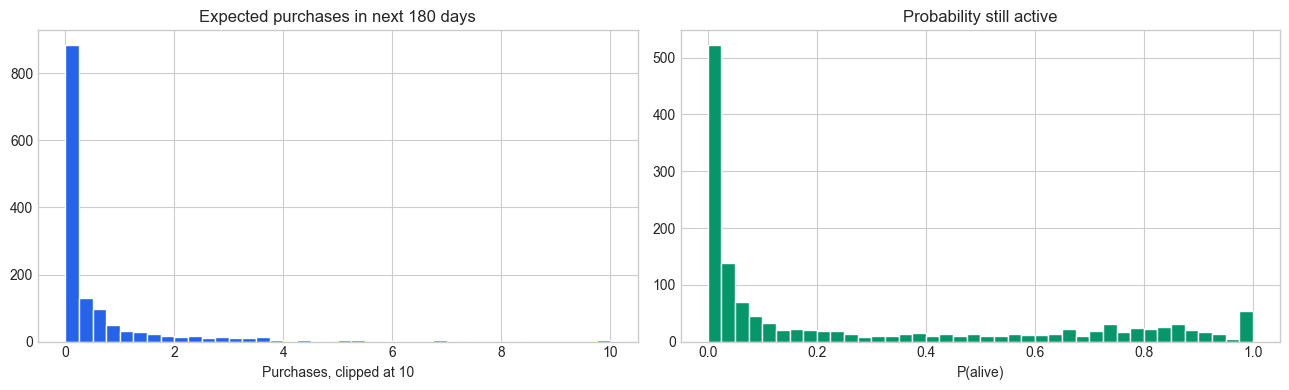

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(rfm["expected_purchases_180d"].clip(upper=10), bins=40, color="#2563EB", edgecolor="white")
axes[0].set_title("Expected purchases in next 180 days")
axes[0].set_xlabel("Purchases, clipped at 10")
axes[1].hist(rfm["p_alive"], bins=40, color="#059669", edgecolor="white")
axes[1].set_title("Probability still active")
axes[1].set_xlabel("P(alive)")
plt.tight_layout()
plt.show()

The spike at `p_alive = 1.0` is a model artifact worth understanding, not a data insight: BG/NBD only flips the dropout coin after a repeat purchase, so a one-time buyer has never had a chance to churn and the model returns exactly 1.0 for every customer with `frequency = 0` - even one who bought once, 600 days ago, and will never return.

In [11]:
inspect_cols = ["customer_id", "frequency", "recency", "T", "monetary_value", "expected_purchases_180d", "p_alive"]
rfm.sort_values("expected_purchases_180d", ascending=False)[inspect_cols].head(10).round(3)

,customer_id,frequency,recency,T,monetary_value,expected_purchases_180d,p_alive
931,BB00931,60.0,417.0,438.0,25.992,14.701,0.782
720,BB00720,43.0,531.0,537.0,25.536,11.189,0.961
410,BB00410,45.0,595.0,596.0,55.803,10.909,0.974
133,BB00133,40.0,478.0,490.0,35.454,10.903,0.934
904,BB00904,48.0,628.0,642.0,24.948,10.550,0.940
409,BB00409,32.0,443.0,467.0,28.325,8.389,0.857
426,BB00426,31.0,520.0,544.0,33.391,7.440,0.882
1335,BB01335,27.0,555.0,556.0,68.139,6.982,0.960
801,BB00801,26.0,541.0,544.0,24.200,6.820,0.955
527,BB00527,18.0,336.0,340.0,22.623,6.765,0.934


## 5. Validate with a calibration and holdout split

We still need a backtest.

This time we cannot use the `lifetimes` calibration helper. We manually:

1. Keep transactions up to the calibration date.
2. Build RFM from that earlier history.
3. Fit BG/NBD on calibration RFM.
4. Predict purchases in the holdout window.
5. Compare with actual holdout purchases (counted as distinct purchase days, the same occasion convention as everywhere else).

In [12]:
calibration_end = observation_end - pd.Timedelta(days=180)
cal_tx = transactions[transactions["order_date"] <= calibration_end].copy()
holdout_tx = transactions[(transactions["order_date"] > calibration_end) & (transactions["order_date"] <= observation_end)].copy()

cal_rfm = build_rfm_by_hand(cal_tx, calibration_end)
holdout_counts = holdout_tx.groupby("customer_id")["order_date"].nunique().rename("frequency_holdout")
cal_rfm = cal_rfm.merge(holdout_counts, on="customer_id", how="left")
cal_rfm["frequency_holdout"] = cal_rfm["frequency_holdout"].fillna(0.0)

bgm_cal = clv.BetaGeoModel(data=cal_rfm, model_config=model_config)
bgm_cal.build_model()
bgm_cal.fit(method="map", progressbar=False)

holdout_days = (observation_end - calibration_end).days
cal_rfm["predicted_holdout_purchases"] = mean_over_posterior(bgm_cal.expected_purchases(future_t=holdout_days))

eval_df = cal_rfm.replace([np.inf, -np.inf], np.nan).dropna(subset=["frequency_holdout", "predicted_holdout_purchases"])
mae = np.mean(np.abs(eval_df["frequency_holdout"] - eval_df["predicted_holdout_purchases"]))
rmse = np.sqrt(np.mean((eval_df["frequency_holdout"] - eval_df["predicted_holdout_purchases"]) ** 2))
rank_corr = eval_df[["frequency_holdout", "predicted_holdout_purchases"]].corr(method="spearman").iloc[0, 1]
total_predicted = eval_df["predicted_holdout_purchases"].sum()
total_actual = eval_df["frequency_holdout"].sum()

print(f"Holdout window: {holdout_days} days")
print(f"Evaluated customers: {len(eval_df):,} of {len(cal_rfm):,}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Spearman rank correlation: {rank_corr:.3f}")
print(f"Total purchases, predicted vs actual: {total_predicted:,.0f} vs {total_actual:,.0f} "
      f"({(total_predicted / total_actual - 1) * 100:+.1f}% bias)")
eval_df[["frequency", "recency", "T", "frequency_holdout", "predicted_holdout_purchases"]].head()

Holdout window: 180 days
Evaluated customers: 1,400 of 1,400
MAE: 0.817
RMSE: 1.540
Spearman rank correlation: 0.591
Total purchases, predicted vs actual: 1,321 vs 1,235 (+6.9% bias)


,frequency,recency,T,frequency_holdout,predicted_holdout_purchases
0,1.0,7.0,550.0,0.0,0.007083
1,3.0,117.0,261.0,0.0,0.499777
2,1.0,94.0,215.0,0.0,0.552825
3,1.0,62.0,445.0,0.0,0.061260
4,1.0,38.0,140.0,2.0,0.571016


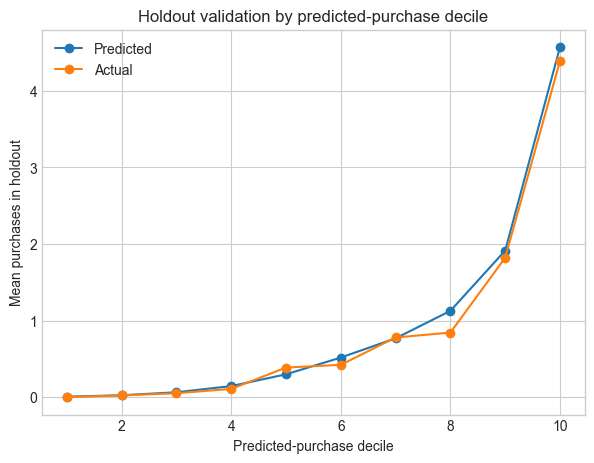

,customers,predicted_purchases,actual_purchases
0,140,0.005,0.000
1,140,0.024,0.021
2,140,0.063,0.050
3,140,0.143,0.107
4,140,0.298,0.386
5,140,0.516,0.421
6,140,0.768,0.779
7,140,1.127,0.843
8,140,1.915,1.821
9,140,4.573,4.393


In [13]:
plot_df = eval_df.copy()
plot_df["pred_bin"] = pd.qcut(plot_df["predicted_holdout_purchases"], q=10, duplicates="drop")
calibration_table = plot_df.groupby("pred_bin", observed=True).agg(
    customers=("frequency_holdout", "size"),
    predicted_purchases=("predicted_holdout_purchases", "mean"),
    actual_purchases=("frequency_holdout", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(calibration_table.index + 1, calibration_table["predicted_purchases"], marker="o", label="Predicted")
ax.plot(calibration_table.index + 1, calibration_table["actual_purchases"], marker="o", label="Actual")
ax.set_title("Holdout validation by predicted-purchase decile")
ax.set_xlabel("Predicted-purchase decile")
ax.set_ylabel("Mean purchases in holdout")
ax.legend()
plt.show()
calibration_table[["customers", "predicted_purchases", "actual_purchases"]].round(3)

Reading the table: the ranking is what matters most, and it is monotone - each decile buys more in the holdout than the one below it, with the top decile at roughly 4.6 predicted versus 4.4 actual purchases. Calibration is decent but not flawless: summed over all customers, the model over-predicts holdout volume by about 7%, with most of the gap in the upper-middle deciles (decile 8 predicts 1.13 versus 0.84 actual). The bottom decile also over-predicts, but at 0.005 versus 0.000 purchases per customer the absolute error is negligible. For ranking-driven decisions - who gets the retention budget - this model is fit for purpose.

## 6. Fit Gamma-Gamma with PyMC-Marketing

Gamma-Gamma estimates the expected average order value.

We only fit it on repeat customers with positive monetary value. That is not a software quirk; the model needs an observed repeat-purchase average to learn customer-level spend.

Before fitting we check the correlation between frequency and monetary value. Gamma-Gamma assumes how often a customer buys is independent of how much they spend per order; a correlation near zero supports that assumption, while a strong one (say frequent buyers systematically placing bigger orders) would bias the spend estimates and call for a different model.

One more deliberate choice: we state priors explicitly. PyMC-Marketing's default for Gamma-Gamma is improper flat priors (`HalfFlat`), and under MAP a flat prior silently turns "Bayesian estimation" into plain maximum likelihood. Nothing wrong with MLE, but it should be a decision, not an accident - so we always state priors for every model. The same scaling logic as before applies: `p` and `q` are shape parameters (HalfNormal(10)), while `v` is on the scale of order values in currency units, so it gets HalfNormal(100).

In [14]:
repeat_customers = rfm[(rfm["frequency"] > 0) & (rfm["monetary_value"] > 0)].copy()
frequency_monetary_corr = repeat_customers[["frequency", "monetary_value"]].corr().iloc[0, 1]
print(f"Correlation between frequency and monetary_value: {frequency_monetary_corr:.3f}")

gg_model_config = {
    "p": Prior("HalfNormal", sigma=10),
    "q": Prior("HalfNormal", sigma=10),
    "v": Prior("HalfNormal", sigma=100),  # scale of order values in currency units
}
gg = clv.GammaGammaModel(data=repeat_customers, model_config=gg_model_config)
gg.build_model()
gg.fit(method="map", progressbar=False)

print("Gamma-Gamma MAP parameters")
display(gg.fit_summary().to_frame("value").round(4))

expected_spend = gg.expected_customer_spend(data=repeat_customers)
repeat_customers["expected_avg_order_value"] = mean_over_posterior(expected_spend)
repeat_customers[["monetary_value", "expected_avg_order_value"]].describe().round(2)

Correlation between frequency and monetary_value: -0.024


Gamma-Gamma MAP parameters


,value
p,5.872
q,4.178
v,22.286


,monetary_value,expected_avg_order_value
count,1347.00,1347.00
mean,41.44,41.38
std,34.47,27.26
min,4.66,10.09
25%,23.23,26.62
50%,32.89,34.40
75%,49.68,48.19
max,483.96,431.18


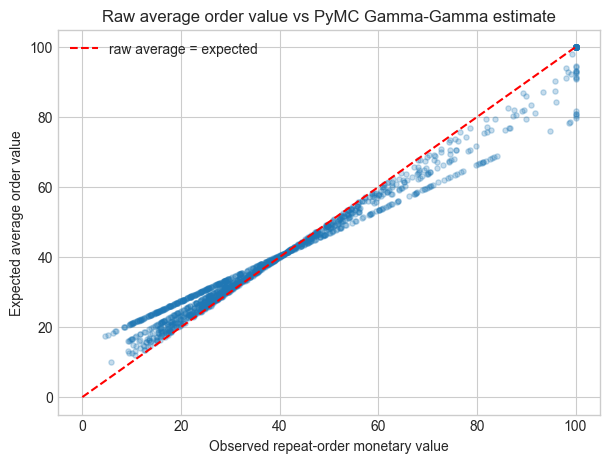

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    repeat_customers["monetary_value"].clip(upper=100),
    repeat_customers["expected_avg_order_value"].clip(upper=100),
    alpha=0.25,
    s=14,
)
ax.plot([0, 100], [0, 100], color="red", linestyle="--", label="raw average = expected")
ax.set_title("Raw average order value vs PyMC Gamma-Gamma estimate")
ax.set_xlabel("Observed repeat-order monetary value")
ax.set_ylabel("Expected average order value")
ax.legend()
plt.show()

## 7. Estimate CLV without `lifetimes`

PyMC-Marketing combines the transaction model and spend model for us.

Watch the units, because this API mixes two conventions and it is an easy trap: `expected_purchases(future_t=180)` measured `future_t` in days (the time unit of the data), but `expected_customer_lifetime_value(future_t=6, time_unit="D", discount_rate=0.01)` measures `future_t` in MONTHS with a monthly discount rate, regardless of the `time_unit` argument - that is how pymc-marketing implements it. So the call below prices six months of future purchases at a 1% monthly discount rate.

We score only the repeat customers here. Gamma-Gamma has nothing customer-specific to say about a `frequency = 0` buyer - it would just hand back the population mean - so leaving such scores in the table invites overinterpretation.

Because we used MAP, the result has one chain and one draw. With MCMC, this same call returns a distribution of CLV values per customer - we collect that payoff in section 8.

In [16]:
rfm_input_cols = ["customer_id", "frequency", "recency", "T", "monetary_value"]

repeat_scored = repeat_customers.copy()

# Pass a .copy(): expected_customer_lifetime_value writes a future_spend
# column into the frame it receives, and we do not want that hidden
# side effect on our own tables.
clv_estimate = gg.expected_customer_lifetime_value(
    transaction_model=bgm,
    data=repeat_scored[rfm_input_cols].copy(),
    future_t=6,          # MONTHS, not days - see the unit warning above
    discount_rate=0.01,  # monthly discount rate
    time_unit="D",
)
repeat_scored["clv_6m"] = mean_over_posterior(clv_estimate)

# Frequency-0 customers are deliberately NOT scored: Gamma-Gamma would only
# return the population-mean spend for them, which is not a customer-level
# estimate.
repeat_scored[["expected_purchases_180d", "expected_avg_order_value", "p_alive", "clv_6m"]].describe().round(2)

,expected_purchases_180d,expected_avg_order_value,p_alive,clv_6m
count,1347.00,1347.00,1347.00,1347.00
mean,0.63,41.38,0.24,25.00
std,1.35,27.26,0.31,61.44
min,0.00,10.09,0.00,0.00
25%,0.01,26.62,0.01,0.34
50%,0.06,34.40,0.05,2.08
75%,0.58,48.19,0.48,19.39
max,14.70,431.18,0.97,846.91


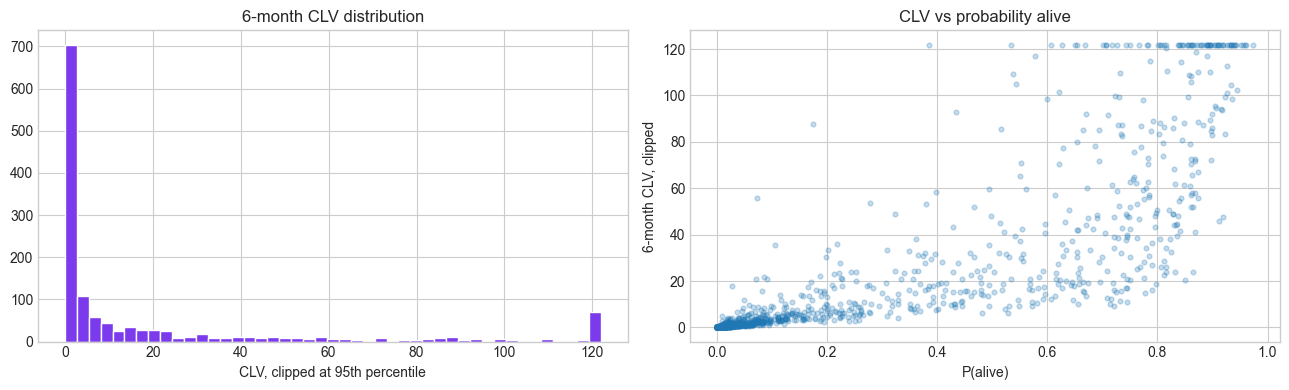

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(repeat_scored["clv_6m"].clip(upper=repeat_scored["clv_6m"].quantile(0.95)), bins=45, color="#7C3AED", edgecolor="white")
axes[0].set_title("6-month CLV distribution")
axes[0].set_xlabel("CLV, clipped at 95th percentile")
axes[1].scatter(repeat_scored["p_alive"], repeat_scored["clv_6m"].clip(upper=repeat_scored["clv_6m"].quantile(0.95)), alpha=0.25, s=12)
axes[1].set_title("CLV vs probability alive")
axes[1].set_xlabel("P(alive)")
axes[1].set_ylabel("6-month CLV, clipped")
plt.tight_layout()
plt.show()

In [18]:
repeat_scored.sort_values("clv_6m", ascending=False)[
    ["customer_id", "frequency", "recency", "T", "monetary_value", "expected_purchases_180d", "p_alive", "expected_avg_order_value", "clv_6m"]
].head(12).round(2)

,customer_id,frequency,recency,T,monetary_value,expected_purchases_180d,p_alive,expected_avg_order_value,clv_6m
335,BB00335,11.0,307.0,317.0,207.86,4.37,0.89,200.05,846.91
410,BB00410,45.0,595.0,596.0,55.80,10.91,0.97,55.63,586.98
297,BB00297,22.0,384.0,426.0,99.34,5.22,0.71,97.94,494.24
1300,BB01300,25.0,439.0,465.0,76.59,6.66,0.86,75.84,488.85
395,BB00395,13.0,598.0,605.0,157.29,3.19,0.92,152.65,471.37
1335,BB01335,27.0,555.0,556.0,68.14,6.98,0.96,67.61,456.60
831,BB00831,31.0,539.0,578.0,64.52,6.28,0.78,64.12,389.45
133,BB00133,40.0,478.0,490.0,35.45,10.90,0.93,35.53,374.77
953,BB00953,9.0,358.0,363.0,119.29,3.36,0.90,114.86,373.90
931,BB00931,60.0,417.0,438.0,25.99,14.70,0.78,26.13,371.64


## 8. The Bayesian payoff: full posteriors

Everything so far used MAP: fast, convenient, and silent about uncertainty. If that is all we wanted, `lifetimes` already did it. The reason to carry PyMC's extra weight is the full posterior, so let us actually pay for it: refit both models with MCMC (4 chains, 1,000 tuning + 1,000 kept draws each).

Two diagnostics gate everything downstream, the same standard as this repo's `03_pymc_analysis.py`: R-hat close to 1 (chains agree with each other) and bulk effective sample size well above 400 (enough independent information in the draws). If either fails, the posterior summaries below would not be trustworthy.

In [19]:
bgm_mcmc = clv.BetaGeoModel(data=rfm[rfm_input_cols], model_config=model_config)
bgm_mcmc.build_model()
bgm_mcmc.fit(chains=4, draws=1000, tune=1000, random_seed=42, cores=4, progressbar=False)

gg_mcmc = clv.GammaGammaModel(data=repeat_customers[rfm_input_cols], model_config=gg_model_config)
gg_mcmc.build_model()
gg_mcmc.fit(chains=4, draws=1000, tune=1000, random_seed=42, cores=4, progressbar=False)

def convergence_gate(model, var_names, label):
    summ = az.summary(model.fit_result, var_names=var_names)
    max_rhat = float(summ["r_hat"].max())
    min_ess = float(summ["ess_bulk"].min())
    ok = (max_rhat < 1.01) and (min_ess > 400)
    print(f"[{label}] max R-hat = {max_rhat:.4f}, min bulk-ESS = {min_ess:.0f} "
          f"-> {'PASS' if ok else 'WARN: inspect trace plots before trusting anything below'}")
    return summ

print("BG/NBD posterior summary (hdi_3% to hdi_97% is the 94% credible interval)")
bgnbd_summary = convergence_gate(bgm_mcmc, ["r", "alpha", "a", "b"], "BG/NBD MCMC")
bgnbd_summary["truth"] = bgnbd_summary.index.map({"r": R_TRUE, "alpha": ALPHA_TRUE, "a": A_TRUE, "b": B_TRUE})
display(bgnbd_summary)

gg_summary = convergence_gate(gg_mcmc, ["p", "q", "v"], "Gamma-Gamma MCMC")
gg_summary["truth"] = gg_summary.index.map({"p": P_SHAPE, "q": Q_TRUE, "v": GAMMA_TRUE})
display(gg_summary)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, a, b, r]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


BG/NBD posterior summary (hdi_3% to hdi_97% is the 94% credible interval)
[BG/NBD MCMC] max R-hat = 1.0000, min bulk-ESS = 1785 -> PASS


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,truth
r,1.426,0.072,1.299,1.565,0.002,0.001,2038.0,2041.0,1.0,1.3
alpha,52.147,3.313,45.934,58.223,0.072,0.060,2105.0,1974.0,1.0,45.0
a,1.226,0.132,1.002,1.480,0.003,0.003,1785.0,2185.0,1.0,1.1
b,3.732,0.548,2.702,4.704,0.012,0.012,2083.0,2034.0,1.0,3.3


[Gamma-Gamma MCMC] max R-hat = 1.0000, min bulk-ESS = 780 -> PASS


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,truth
p,5.991,0.953,4.292,7.815,0.033,0.025,839.0,1122.0,1.0,6.0
q,4.199,0.232,3.771,4.626,0.007,0.005,1042.0,1507.0,1.0,4.0
v,22.637,4.530,13.989,30.557,0.161,0.104,780.0,1128.0,1.0,20.0


Both gates PASS. And because the data are simulated, we can grade the intervals against the truth column. `a` and `b` sit comfortably inside their 94% HDIs. `r` (truth 1.30) and `alpha` (truth 45) both land at the lower edge of theirs - which is really one deviation, not two: the pair is strongly correlated because the likelihood mainly pins down the mean purchase rate `r / alpha`, and the implied posterior rate (about 0.027 purchases per day) is within about 5% of the true 0.029. On the spend side, all three Gamma-Gamma parameters bracket their true values. This is what MAP could never show us: not just where the estimates sit, but how far to trust them.

In [20]:
# Per-customer P(alive) now comes back as a full posterior: 4,000 draws per
# customer. We keep both the posterior mean and the posterior standard
# deviation - the honest "give or take" that MAP could never provide.
p_alive_posterior = bgm_mcmc.expected_probability_alive()
rfm["p_alive_mean"] = p_alive_posterior.mean(("chain", "draw")).to_numpy()
rfm["p_alive_std"] = p_alive_posterior.std(("chain", "draw")).to_numpy()

show = rfm.sort_values("p_alive_std", ascending=False).head(5)
show = show[["customer_id", "frequency", "recency", "T", "p_alive_mean", "p_alive_std"]].copy()
show["p_alive"] = show.apply(lambda r: f"{r.p_alive_mean:.2f} +/- {r.p_alive_std:.2f}", axis=1)
print("Customers where the model is LEAST sure about p_alive:")
show[["customer_id", "frequency", "recency", "T", "p_alive"]]

Customers where the model is LEAST sure about p_alive:


,customer_id,frequency,recency,T,p_alive
979,BB00979,22.0,341.0,386.0,0.62 +/- 0.02
777,BB00777,21.0,619.0,698.0,0.62 +/- 0.02
1008,BB01008,16.0,373.0,444.0,0.51 +/- 0.02
965,BB00965,16.0,512.0,618.0,0.43 +/- 0.02
876,BB00876,17.0,504.0,574.0,0.65 +/- 0.02


In [21]:
# CLV over the posterior. To keep the computation light we thin the chains,
# keeping every 2nd draw: 2,000 draws is still ample for stable means and
# standard deviations.
bgm_thin = bgm_mcmc.thin_fit_result(keep_every=2)
gg_thin = gg_mcmc.thin_fit_result(keep_every=2)

clv_posterior = gg_thin.expected_customer_lifetime_value(
    transaction_model=bgm_thin,
    data=repeat_scored[rfm_input_cols].copy(),
    future_t=6,          # months again, as in section 7
    discount_rate=0.01,
    time_unit="D",
)
repeat_scored["clv_6m_mcmc_mean"] = clv_posterior.mean(("chain", "draw")).to_numpy()
repeat_scored["clv_6m_mcmc_std"] = clv_posterior.std(("chain", "draw")).to_numpy()

top10 = repeat_scored.sort_values("clv_6m_mcmc_mean", ascending=False).head(10).copy()
top10["clv_6m_posterior"] = top10.apply(lambda r: f"{r.clv_6m_mcmc_mean:,.0f} +/- {r.clv_6m_mcmc_std:,.0f}", axis=1)
top10[["customer_id", "frequency", "recency", "T", "monetary_value", "clv_6m", "clv_6m_posterior"]].round(2)

,customer_id,frequency,recency,T,monetary_value,clv_6m,clv_6m_posterior
335,BB00335,11.0,307.0,317.0,207.86,846.91,841 +/- 19
410,BB00410,45.0,595.0,596.0,55.80,586.98,584 +/- 9
297,BB00297,22.0,384.0,426.0,99.34,494.24,488 +/- 20
1300,BB01300,25.0,439.0,465.0,76.59,488.85,484 +/- 13
395,BB00395,13.0,598.0,605.0,157.29,471.37,469 +/- 7
1335,BB01335,27.0,555.0,556.0,68.14,456.60,454 +/- 8
831,BB00831,31.0,539.0,578.0,64.52,389.45,385 +/- 13
133,BB00133,40.0,478.0,490.0,35.45,374.77,372 +/- 8
953,BB00953,9.0,358.0,363.0,119.29,373.90,372 +/- 7
931,BB00931,60.0,417.0,438.0,25.99,371.64,367 +/- 14


These intervals are credible intervals: given the data and the priors, the parameter lies inside the 94% HDI with 94% probability - a direct probability statement about the quantity we care about, which is what stakeholders usually think a confidence interval means (it is not). MAP gave us none of this: no interval on `alpha`, no "give or take" on any customer's `p_alive`, no spread on a CLV estimate before we commit marketing budget to it. The point estimates barely moved between MAP and MCMC here; what we bought is the uncertainty around them, and for the top CLV customers that uncertainty is a material fraction of the estimate itself.

## 9. Turn PyMC output into the same action table

The model changed, but the business decision layer stays familiar. We place each repeat customer on two axes:

- Value: the observed annual run rate (money actually spent per year of tenure). The top 20% counts as high value.
- Risk: the posterior mean of P(alive), with 0.75 as the action threshold.

|  | Still active | Fading (P(alive) < 0.75) |
|---|---|---|
| **High run rate** | Protect | Win back |
| **Lower run rate** | Nurture | Low-touch |

Why not use CLV as the value axis? Because CLV already embeds P(alive) - a valuable-but-fading customer gets a low CLV precisely because the model thinks they are leaving. Crossing CLV with P(alive) would leave the "Win back" quadrant empty by construction, and Win back is the quadrant a retention team exists for. The run rate measures what the relationship was worth while it was healthy; P(alive) measures whether it still is.

In [22]:
scorecard = repeat_scored.merge(rfm[["customer_id", "p_alive_mean", "p_alive_std"]], on="customer_id", how="left")

# Observed value while the relationship lasted: money per year of tenure.
# monetary_value is the average repeat-day spend, frequency + 1 the number of
# purchase days, T / 365 the tenure in years.
scorecard["annual_run_rate"] = scorecard["monetary_value"] * (scorecard["frequency"] + 1) / (scorecard["T"] / 365.0)

high_value = scorecard["annual_run_rate"] >= scorecard["annual_run_rate"].quantile(0.80)
at_risk = scorecard["p_alive_mean"] < 0.75

conditions = [
    high_value & ~at_risk,
    high_value & at_risk,
    ~high_value & ~at_risk,
]
choices = [
    "Protect: high value and active",
    "Win back: valuable but fading",
    "Nurture cheaply: active but lower value",
]
scorecard["recommended_action"] = np.select(conditions, choices, default="Low-touch: low value or inactive")
scorecard.groupby("recommended_action").agg(
    customers=("customer_id", "count"),
    avg_annual_run_rate=("annual_run_rate", "mean"),
    avg_p_alive=("p_alive_mean", "mean"),
    avg_clv_6m=("clv_6m_mcmc_mean", "mean"),
    avg_expected_purchases_180d=("expected_purchases_180d", "mean"),
).sort_values("avg_annual_run_rate", ascending=False).round(2)

,customers,avg_annual_run_rate,avg_p_alive,avg_clv_6m,avg_expected_purchases_180d
recommended_action,,,,,
Protect: high value and active,96,540.08,0.87,176.33,4.25
Win back: valuable but fading,174,488.82,0.20,38.40,0.64
Nurture cheaply: active but lower value,79,143.51,0.82,48.74,1.81
Low-touch: low value or inactive,998,89.30,0.15,6.03,0.19


In [23]:
# One advantage of simulated data: the truth is on file. How well does the
# posterior mean of p_alive separate customers who are truly still alive from
# those who already dropped out?
from sklearn.metrics import roc_auc_score

truth = rfm.merge(customers[["customer_id", "alive_at_observation_end_hidden"]], on="customer_id")
auc = roc_auc_score(truth["alive_at_observation_end_hidden"].astype(int), truth["p_alive_mean"])
print(f"AUC of p_alive_mean against the hidden alive-at-end truth: {auc:.3f}")

AUC of p_alive_mean against the hidden alive-at-end truth: 0.941


## 10. What we gained and what we paid

What we gained:

- No dependency on `lifetimes`.
- Direct probabilistic model objects.
- Posterior uncertainty we actually used: credible intervals on parameters, a standard deviation on every customer's P(alive) and CLV.
- Custom priors, stated explicitly for every model.
- A path to hierarchical or covariate-rich BTYD models.

What we paid:

- More dependencies.
- More fitting time (minutes of MCMC instead of seconds of MLE).
- More statistical responsibility: prior scaling, convergence diagnostics, unit conventions.

A good workflow is: learn the mechanics with `lifetimes`, then move to PyMC when uncertainty, priors, or model customization matter.

## Final consultant summary

We rebuilt the same BTYD project without `lifetimes`, on the same simulated business as the sibling notebook: same generator, same seed, same 1,400 customers. We built RFM by hand under the same purchase-occasion convention, fitted BG/NBD and Gamma-Gamma through PyMC-Marketing with explicitly stated and properly scaled priors, validated future purchase predictions on a 180-day holdout (Spearman rank correlation 0.59, total volume over-predicted by about 7%), and estimated 6-month CLV.

Then we collected the payoff that justifies PyMC in the first place: MCMC posteriors that pass the convergence gate (max R-hat 1.00, minimum bulk-ESS well above 400), 94% credible intervals for every parameter, and an uncertainty band on every customer's P(alive) and CLV. Checked against the simulation's hidden truth, the posterior mean of P(alive) separates truly-active from silently-departed customers with an AUC of 0.94. The action table sorts the 1,347 repeat customers into Protect (96), Win back (174), Nurture (79), and Low-touch (998).

The modeling mindset is unchanged: BTYD is still about repeat purchases, hidden dropout, expected spend, and decision quality. PyMC simply gives us a more extensible probabilistic engine - and, once we run MCMC, an honest account of its own uncertainty.